# ANALYSIS SOLAR 2. tpeanuts

Each section states what is being computed or checked before running the numerical block. The notebook follows the root `run*.py` workflows, but expands them into reusable diagnostics for solar production, Earth propagation, annual averaging, and detected flavour content using the torch-native `tpeanuts` API.


## 1. Libraries

This section imports the numerical, plotting, filesystem, and torch libraries used by the analysis.


In [1]:
from __future__ import annotations

import math
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch


from tpeanuts.core.pmns import PMNS
from tpeanuts.solar.profiles import load_default_solar_profile
from tpeanuts.solar.probabilities import psolar, solar_flux_mass
from tpeanuts.io.io_earth import load_earth_density_from_csv
from tpeanuts.earth.probabilities import pearth, pearth_analytical, pearth_numerical
from tpeanuts.earth.exposure import build_nadir_exposure

from tpeanuts.util.notebooks import find_repo_root, save_and_show, save_figure, show_figure
from tpeanuts.util.solar import load_spectrum_table, normalized_spectrum, relative_flux_density
HERE = Path.cwd().resolve()
PACKAGE_DIR = find_repo_root(HERE, folder="analysis")
print(f"PACKAGE_DIR = {PACKAGE_DIR}")


PACKAGE_DIR = G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts


## 2. Paths and Configuration

This section separates filesystem discovery from the physics and plotting parameters used below.


### 2.1. Paths

This subsection locates the repository, data folders, spectrum files, Earth-density tables, and output directory.


In [2]:
DATA_DIR = PACKAGE_DIR / "data"
LEGACY_DATA_DIR = DATA_DIR / "peanuts"
SOLAR_DATA_DIR = DATA_DIR / "solar"
SOLAR_SPECTRA_DIR = SOLAR_DATA_DIR / "spectra"
EARTH_DENSITY_TPEANUTS = DATA_DIR / "density" / "earth_density.csv"
EARTH_DENSITY_LEGACY = LEGACY_DATA_DIR / "Earth_Density.csv"

DEFAULT_OUTPUT_ROOT = Path(r"V:\output")
OUTPUT_ROOT = Path(os.environ.get("TPEANUTS_OUTPUT_ROOT", DEFAULT_OUTPUT_ROOT))

OUTPUT_DATA_ROOT = Path(OUTPUT_ROOT / "data")
OUTPUT_ANALYSIS_ROOT = Path(OUTPUT_ROOT / "analysis")
OUTPUT_BENCHMARK_ROOT = Path(OUTPUT_ROOT / "benchmark")
OUTPUT_TEST_ROOT = Path(OUTPUT_ROOT / "test")

OUTPUT_DATA_ATMOSPHERE = Path(OUTPUT_DATA_ROOT / "atmosphere")
OUTPUT_DATA_SOLAR = Path(OUTPUT_DATA_ROOT / "solar")
OUTPUT_DATA_EXTERNAL = Path(OUTPUT_DATA_ROOT / "external")

OUTPUT_ANALYSIS_ATMOSPHERE = Path(OUTPUT_ANALYSIS_ROOT / "atmosphere")
OUTPUT_ANALYSIS_SOLAR = Path(OUTPUT_ANALYSIS_ROOT / "solar")
OUTPUT_ANALYSIS_EXTERNAL = Path(OUTPUT_ANALYSIS_ROOT / "external")

OUTPUT_DATA_MCEQ = Path(OUTPUT_DATA_ROOT / "mceq")
OUTPUT_DATA_HONDA = Path(OUTPUT_DATA_ROOT / "honda")

OUTPUT_DIR = OUTPUT_ANALYSIS_SOLAR / "analysis_solar2_tpeanuts"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


SHOW_PLOTS = True

print("Output root     :", OUTPUT_ROOT)
print("Output directory:", OUTPUT_DIR)


Output root     : V:\output
Output directory: V:\output\analysis\solar\analysis_solar2_tpeanuts


### 2.2. Configuration Parameters

This subsection defines mixing parameters, energy grids, detector settings, annual exposure settings, and imports the torch-native `tpeanuts` API corresponding to the root `run*.py` workflows.


In [3]:
DEVICE = torch.device("cpu")
DTYPE = torch.float64
CDTYPE = torch.complex128

THETA12 = 0.59
THETA13 = 0.15
THETA23 = 0.78
DELTA_CP = 1.20
DM21_EV2 = 7.42e-5
DM3L_EV2 = 2.517e-3

FLAVOUR_LABELS = [r"$\nu_e$", r"$\nu_\mu$", r"$\nu_\tau$"]
SOURCE_ORDER = ["pp", "7Be", "8B", "hep", "13N", "15O", "17F"]
ENERGY_MEV = np.linspace(0.2, 18.0, 90)
EARTH_METHOD_ENERGY_MEV = np.linspace(1.0, 18.0, 18)
EARTH_ENERGY_MEV = 10.0
EARTH_DEPTH_M = 2000.0
NADIR_ANGLES = [0.25 * math.pi, 0.50 * math.pi, 0.75 * math.pi]
SOLAR_DETECTOR_NADIR = 0.25 * math.pi
SOLAR_DETECTOR_ENERGY_MEV = 10.0
EARTH_PROPAGATION_METHOD = "analytical"
EARTH_NUMERICAL_NSTEPS = 120
EARTH_NUMERICAL_ODE_METHOD = "midpoint"
DETECTOR_LATITUDE_RAD = math.radians(42.0)
ANNUAL_NADIR_SAMPLES = 13
ANNUAL_ENERGY_MEV = np.linspace(0.5, 18.0, 24)
NADIR_EXPOSURE_SOURCE = "math"
NADIR_EXPOSURE_CACHE_DIR = str(OUTPUT_DIR / "nadir_exposure_cache")
NADIR_EXPOSURE_CSV = OUTPUT_DIR / "nadir_exposure_reference.csv"
SECONDS_PER_YEAR = 365.25 * 24.0 * 3600.0
DETECTOR_AREA_CM2 = 1.0

plt.rcParams.update({"figure.figsize": (8, 4.8), "axes.grid": True, "grid.alpha": 0.3})



### 2.3. Helper Functions


In [4]:
def plot_probability_and_flux(energy_mev: np.ndarray, probabilities: np.ndarray, fluxes: np.ndarray, title: str) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharex=True)
    for i, label in enumerate(FLAVOUR_LABELS):
        axes[0].plot(energy_mev, probabilities[:, i], label=label)
        axes[1].plot(energy_mev, fluxes[:, i], label=label)
    axes[0].set_xlabel("Energy [MeV]")
    axes[0].set_ylabel("Probability")
    axes[0].set_title("Detector probabilities")
    axes[1].set_xlabel("Energy [MeV]")
    axes[1].set_ylabel(r"Flux [cm$^{-2}$ s$^{-1}$ MeV$^{-1}$]")
    axes[1].set_yscale('log')
    axes[1].set_title("Detected flavour flux")
    axes[0].legend()
    axes[1].legend()
    fig.suptitle(title, fontsize=15)
    fig.tight_layout()
    save_and_show(output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)


pmns = PMNS(THETA12, THETA13, THETA23, DELTA_CP, device=DEVICE, real_dtype=DTYPE)
solar_profile = load_default_solar_profile(device=DEVICE, dtype=DTYPE)
earth_density = load_earth_density_from_csv(str(EARTH_DENSITY_TPEANUTS), tabulated_density=False, device=DEVICE, dtype=DTYPE)
available_sources = [s for s in SOURCE_ORDER if s in solar_profile.fractions]
print("tpeanuts solar sources:", available_sources)


tpeanuts solar sources: ['pp', '7Be', '8B', 'hep', '13N', '15O', '17F']


### 2.4. Solar and Earth Density Profiles

This subsection checks the electron-density profiles used by the solar and Earth propagation calculations.


Saved figure: V:\output\analysis\solar\analysis_solar2_tpeanuts\figure_001.png


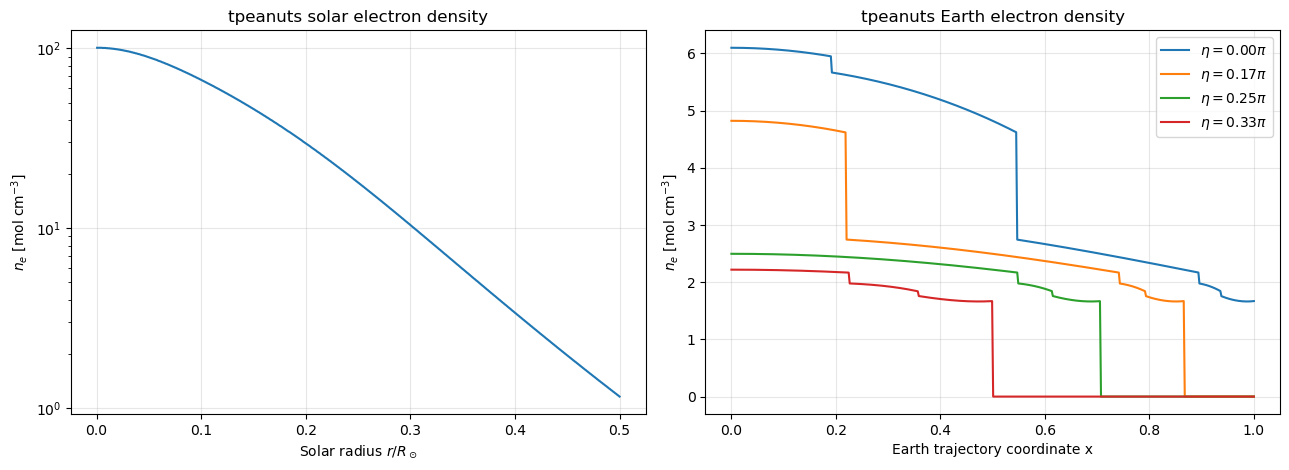

WindowsPath('V:/output/analysis/solar/analysis_solar2_tpeanuts/figure_001.png')

In [5]:
radius = solar_profile.radius.detach().cpu().numpy()
solar_density = solar_profile.density.detach().cpu().numpy()
x = torch.linspace(0.0, 1.0, 500, dtype=DTYPE, device=DEVICE)
etas = torch.tensor([0.0, math.pi / 6.0, math.pi / 4.0, math.pi / 3.0], dtype=DTYPE, device=DEVICE)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].semilogy(radius, solar_density)
axes[0].set_xlabel(r"Solar radius $r/R_\odot$")
axes[0].set_ylabel(r"$n_e$ [mol cm$^{-3}$]")
axes[0].set_title("tpeanuts solar electron density")

for eta in etas:
    y = earth_density.call(x, eta).detach().cpu().numpy()
    axes[1].plot(x.detach().cpu().numpy(), y, label=rf"$\eta={float(eta/math.pi):.2f}\pi$")
axes[1].set_xlabel("Earth trajectory coordinate x")
axes[1].set_ylabel(r"$n_e$ [mol cm$^{-3}$]")
axes[1].set_title("tpeanuts Earth electron density")
axes[1].legend()
fig.tight_layout()
save_and_show(output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)


## 3. Solar Production

This section checks where neutrinos are produced in the Sun and how each source maps into flavour probabilities before crossing Earth.


### 3.1. Production Profiles

This subsection plots the radial production profile for each solar neutrino source.


Saved figure: V:\output\analysis\solar\analysis_solar2_tpeanuts\figure_002.png


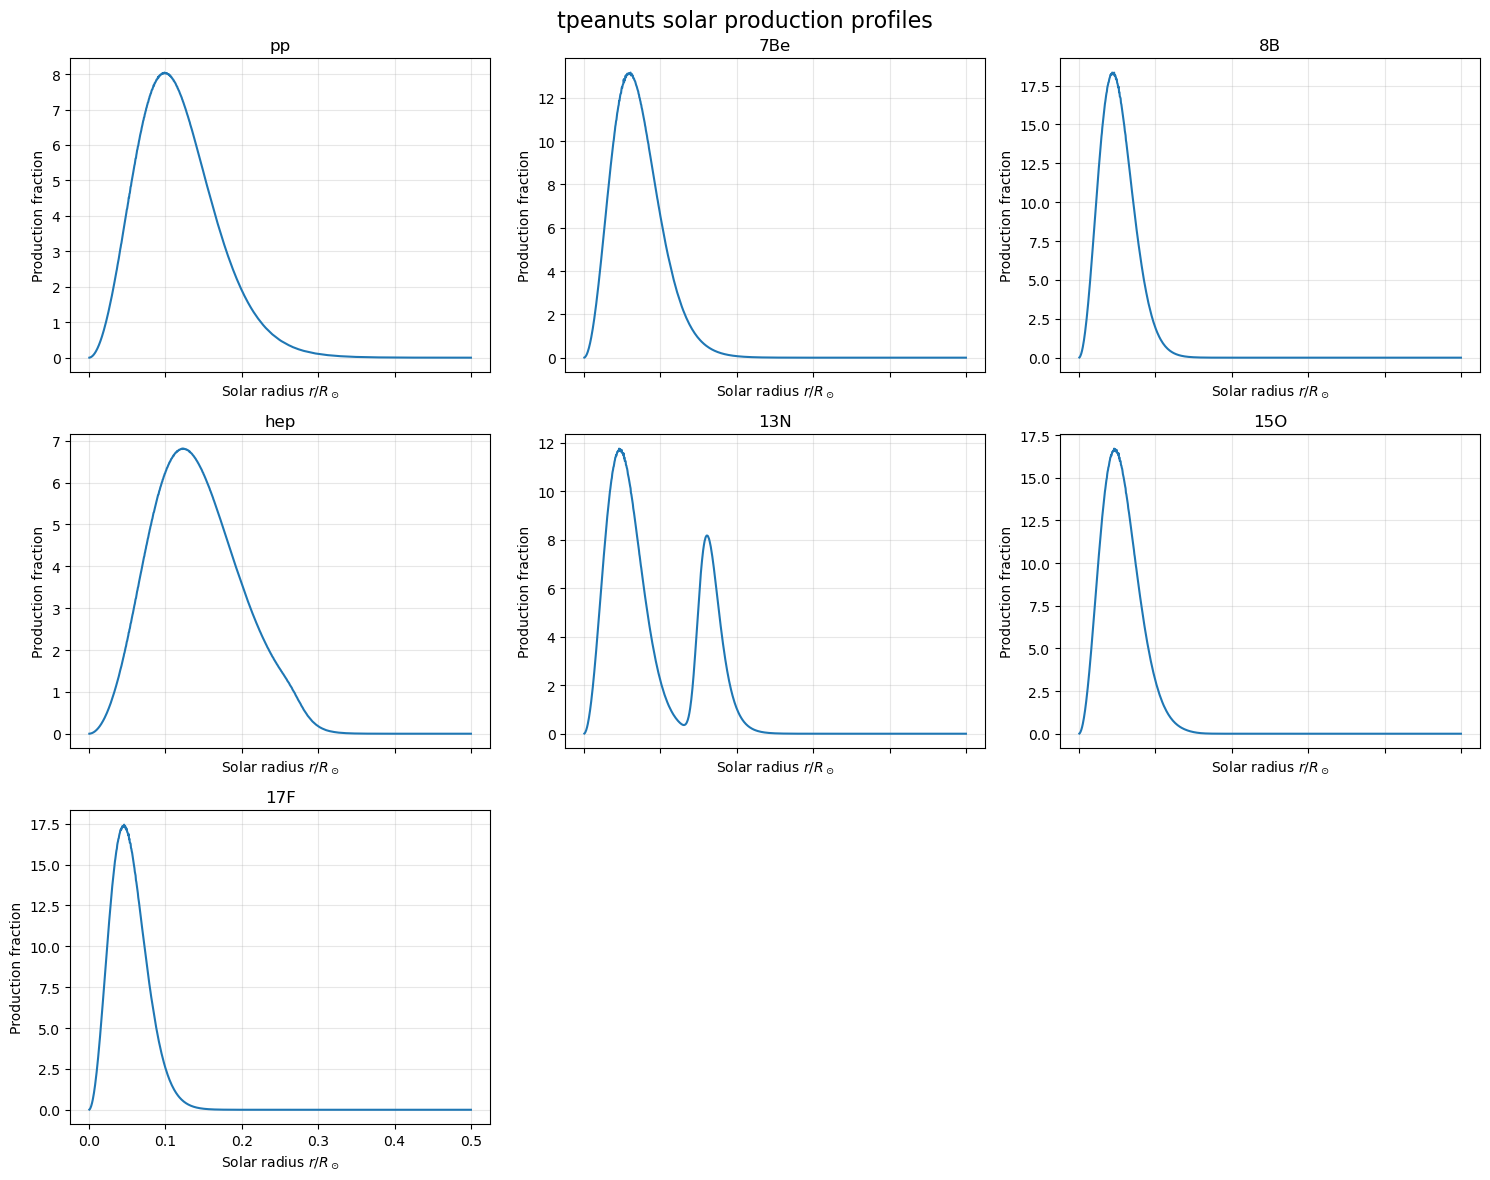

WindowsPath('V:/output/analysis/solar/analysis_solar2_tpeanuts/figure_002.png')

In [6]:
ncols = 3
nrows = int(np.ceil(len(available_sources) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows), sharex=True)
axes = np.asarray(axes).reshape(-1)
for ax, source in zip(axes, available_sources):
    ax.plot(solar_profile.radius.detach().cpu(), solar_profile.production_fraction(source).detach().cpu())
    ax.set_title(source)
    ax.set_xlabel(r"Solar radius $r/R_\odot$")
    ax.set_ylabel("Production fraction")
for ax in axes[len(available_sources):]:
    ax.axis("off")
fig.suptitle("tpeanuts solar production profiles", fontsize=16)
fig.tight_layout()
save_and_show(output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)


### 3.2. Solar Flavour Production by Source

This subsection computes the solar flavour probabilities for every source and energy point.


Saved figure: V:\output\analysis\solar\analysis_solar2_tpeanuts\figure_003.png


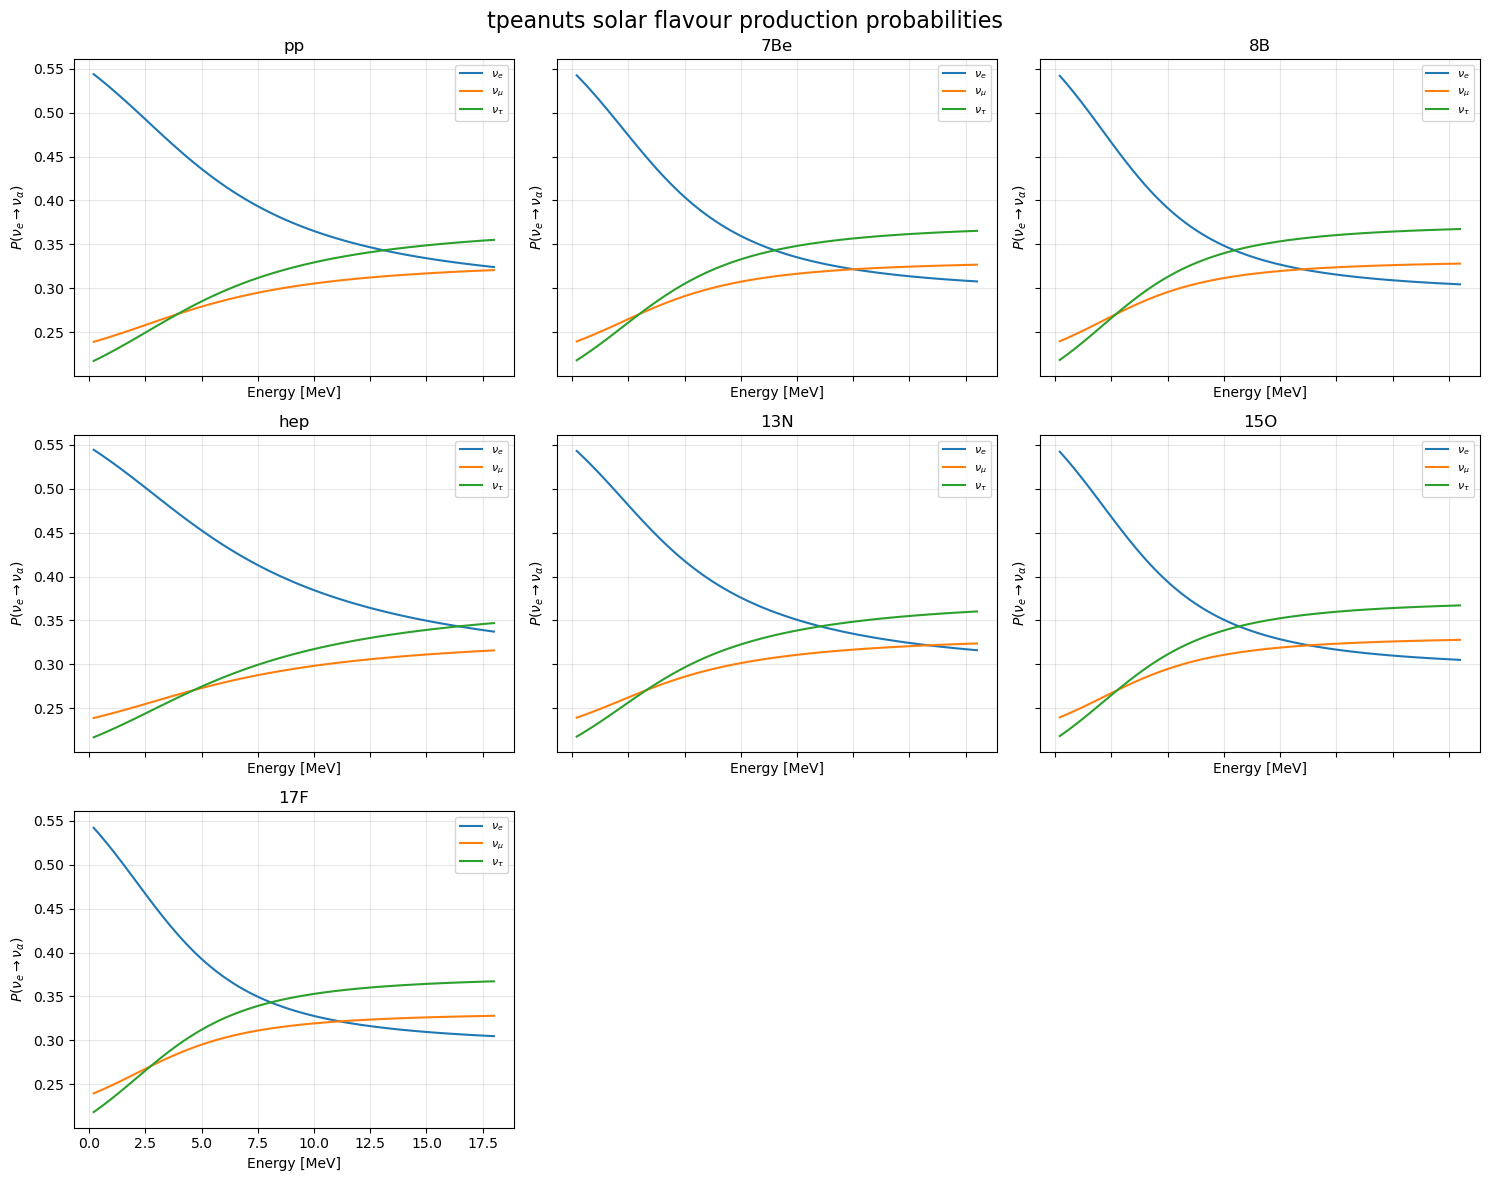

WindowsPath('V:/output/analysis/solar/analysis_solar2_tpeanuts/figure_003.png')

In [7]:
E_t = torch.as_tensor(ENERGY_MEV, dtype=DTYPE, device=DEVICE)
ncols = 3
nrows = int(np.ceil(len(available_sources) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows), sharex=True, sharey=True)
axes = np.asarray(axes).reshape(-1)
for ax, source in zip(axes, available_sources):
    probs = psolar(pmns, DM21_EV2, DM3L_EV2, E_t, solar_profile.radius, solar_profile.density, solar_profile.production_fraction(source))
    probs_np = probs.detach().cpu().numpy()
    for i, label in enumerate(FLAVOUR_LABELS):
        ax.plot(ENERGY_MEV, probs_np[:, i], label=label)
    ax.set_title(source)
    ax.set_xlabel("Energy [MeV]")
    ax.set_ylabel(r"$P(\nu_e\to\nu_\alpha)$")
    ax.legend(fontsize=8)
for ax in axes[len(available_sources):]:
    ax.axis("off")
fig.suptitle("tpeanuts solar flavour production probabilities", fontsize=16)
fig.tight_layout()
save_and_show(output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)


## 4. Earth Analytical vs Numerical `pearth`

This section compares analytical and numerical Earth propagation for a grid of energies and nadir angles. The left panel overlays the electron-flavour component from both methods, while the right panel shows the maximum relative difference across final flavours.


E=1.00 MeV | eta=0.25 pi | max relative error=1.581e-03
E=1.00 MeV | eta=0.50 pi | max relative error=4.287e-13
E=1.00 MeV | eta=0.75 pi | max relative error=1.189e-14
E=2.00 MeV | eta=0.25 pi | max relative error=1.245e-03
E=2.00 MeV | eta=0.50 pi | max relative error=1.596e-13
E=2.00 MeV | eta=0.75 pi | max relative error=8.090e-14
E=3.00 MeV | eta=0.25 pi | max relative error=1.117e-03
E=3.00 MeV | eta=0.50 pi | max relative error=1.539e-13
E=3.00 MeV | eta=0.75 pi | max relative error=1.485e-13
E=4.00 MeV | eta=0.25 pi | max relative error=9.616e-04
E=4.00 MeV | eta=0.50 pi | max relative error=4.641e-13
E=4.00 MeV | eta=0.75 pi | max relative error=1.080e-14
E=5.00 MeV | eta=0.25 pi | max relative error=1.787e-04
E=5.00 MeV | eta=0.50 pi | max relative error=1.152e-13
E=5.00 MeV | eta=0.75 pi | max relative error=5.862e-08
E=6.00 MeV | eta=0.25 pi | max relative error=2.343e-03
E=6.00 MeV | eta=0.50 pi | max relative error=1.216e-13
E=6.00 MeV | eta=0.75 pi | max relative error=4.

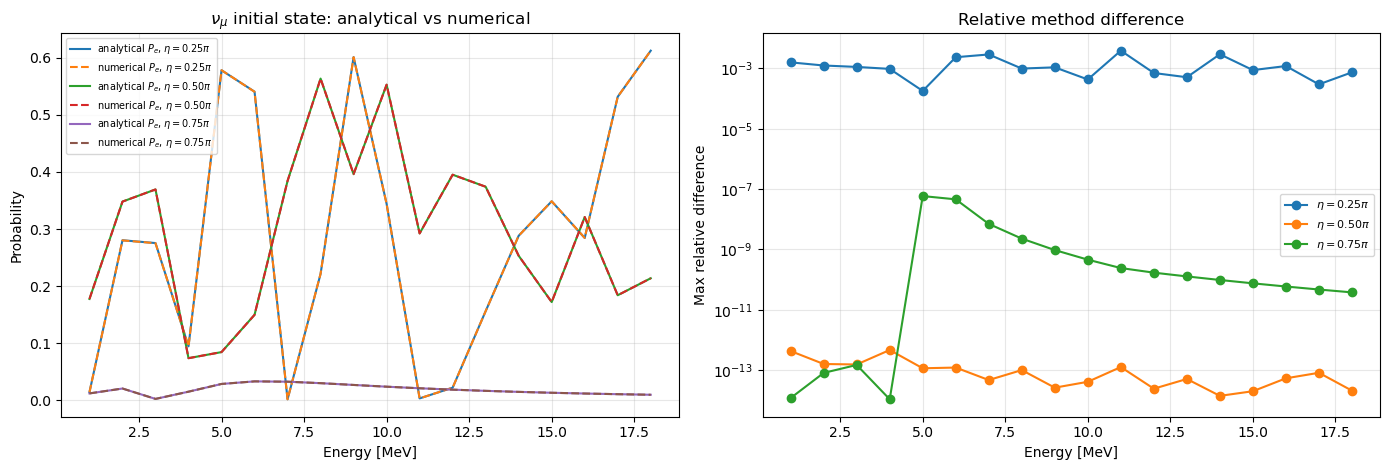

WindowsPath('V:/output/analysis/solar/analysis_solar2_tpeanuts/figure_004.png')

In [8]:
state = torch.tensor([0.0, 1.0, 0.0], dtype=CDTYPE, device=DEVICE)
comparison_etas = np.asarray(NADIR_ANGLES, dtype=float)
P_an_grid = np.zeros((len(EARTH_METHOD_ENERGY_MEV), len(comparison_etas), 3))
P_num_grid = np.zeros_like(P_an_grid)

for iE, E_case in enumerate(EARTH_METHOD_ENERGY_MEV):
    for j, eta_case in enumerate(comparison_etas):
        E_t = torch.tensor(float(E_case), dtype=DTYPE, device=DEVICE)
        eta_t = torch.tensor(float(eta_case), dtype=DTYPE, device=DEVICE)
        P_an = pearth_analytical(state, earth_density, pmns, DM21_EV2, DM3L_EV2, E_t, eta_t, EARTH_DEPTH_M, massbasis=False)
        P_num = pearth_numerical(state, earth_density, pmns, DM21_EV2, DM3L_EV2, E_t, eta_t, EARTH_DEPTH_M, massbasis=False, nsteps=80, ode_method="midpoint", device=DEVICE, dtype=DTYPE)
        P_an_grid[iE, j] = P_an.detach().cpu().numpy()
        P_num_grid[iE, j] = P_num.detach().cpu().numpy()

rel_grid = np.max(np.abs(P_num_grid - P_an_grid) / np.maximum(np.abs(P_an_grid), 1.0e-15), axis=-1)
for iE, E_case in enumerate(EARTH_METHOD_ENERGY_MEV):
    for j, eta_case in enumerate(comparison_etas):
        print(f"E={E_case:.2f} MeV | eta={eta_case/math.pi:.2f} pi | max relative error={rel_grid[iE, j]:.3e}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharex=True)
for j, eta_case in enumerate(comparison_etas):
    axes[0].plot(EARTH_METHOD_ENERGY_MEV, P_an_grid[:, j, 0], "-", label=rf"analytical $P_e$, $\eta={eta_case/math.pi:.2f}\pi$")
    axes[0].plot(EARTH_METHOD_ENERGY_MEV, P_num_grid[:, j, 0], "--", label=rf"numerical $P_e$, $\eta={eta_case/math.pi:.2f}\pi$")
    axes[1].plot(EARTH_METHOD_ENERGY_MEV, rel_grid[:, j], marker="o", label=rf"$\eta={eta_case/math.pi:.2f}\pi$")
axes[0].set_xlabel("Energy [MeV]")
axes[0].set_ylabel("Probability")
axes[0].set_title(r"$\nu_\mu$ initial state: analytical vs numerical")
axes[1].set_xlabel("Energy [MeV]")
axes[1].set_ylabel("Max relative difference")
axes[1].set_yscale("log")
axes[1].set_title("Relative method difference")
axes[0].legend(fontsize=7)
axes[1].legend(fontsize=8)
fig.tight_layout()
save_and_show(output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)


## 5. Pure-State Earth Oscillations

This section propagates pure electron, muon, and tau flavour states through Earth for three fixed nadir angles.


Saved figure: V:\output\analysis\solar\analysis_solar2_tpeanuts\figure_005.png


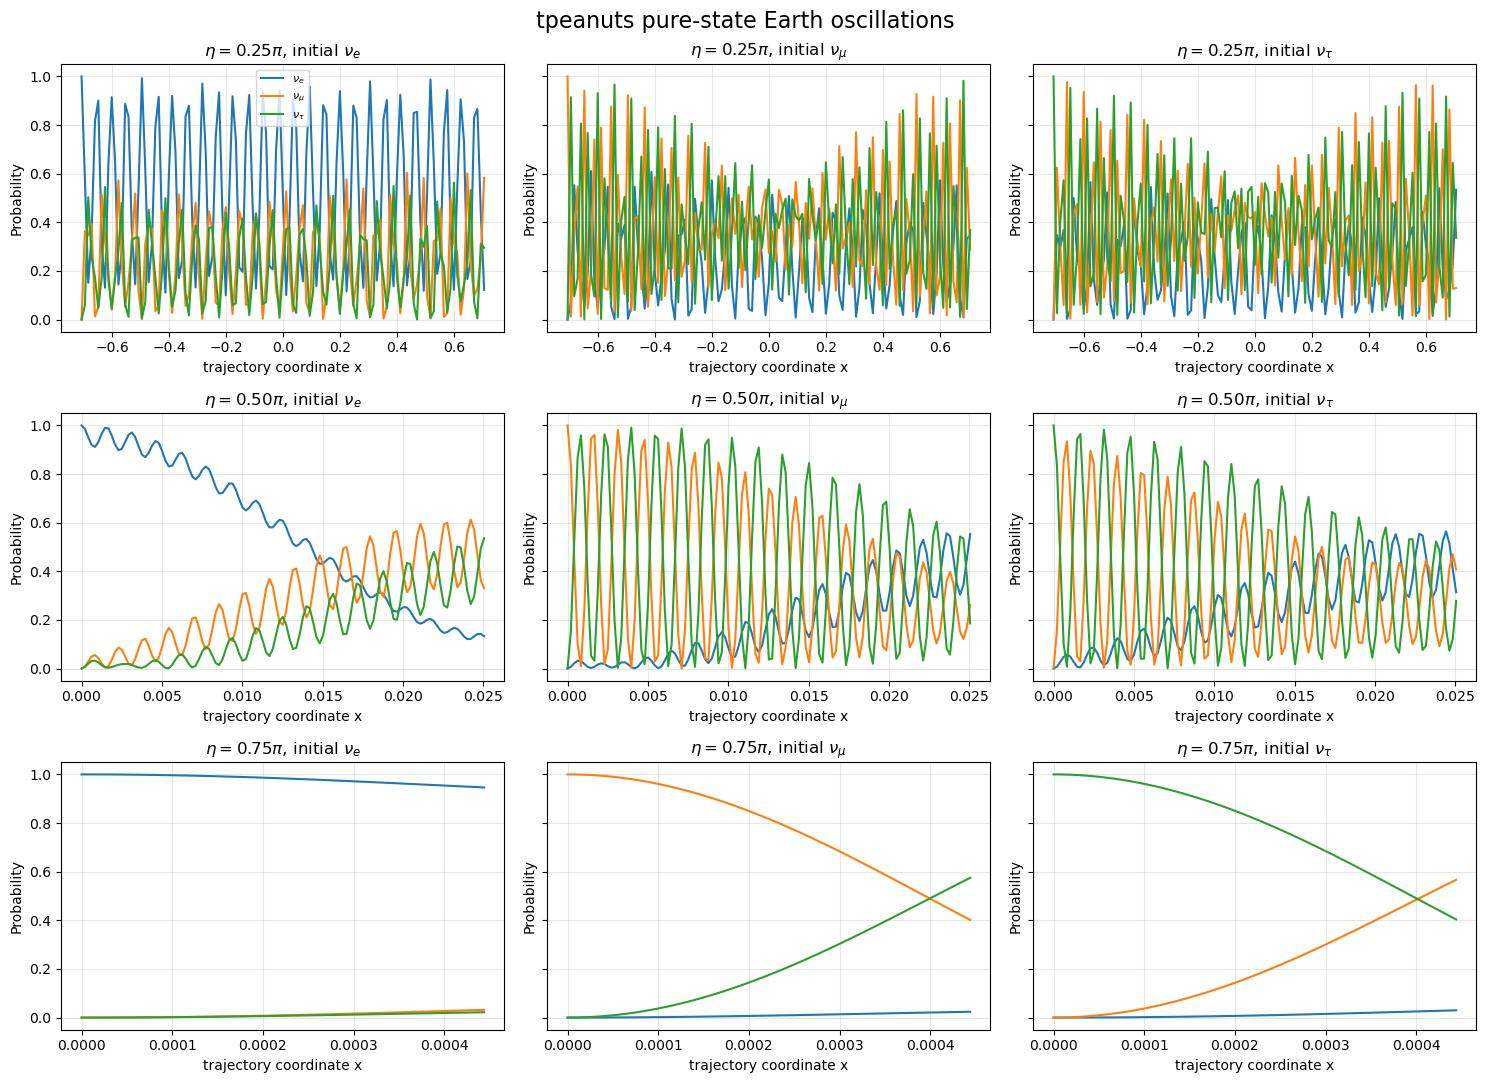

WindowsPath('V:/output/analysis/solar/analysis_solar2_tpeanuts/figure_005.png')

In [9]:
initial_states = [torch.eye(3, dtype=CDTYPE, device=DEVICE)[i] for i in range(3)]
fig, axes = plt.subplots(3, 3, figsize=(15, 11), sharex=False, sharey=True)
for row, eta in enumerate(NADIR_ANGLES):
    for col, state in enumerate(initial_states):
        sol, x = pearth_numerical(state, earth_density, pmns, DM21_EV2, DM3L_EV2, torch.tensor(EARTH_ENERGY_MEV, dtype=DTYPE), torch.tensor(eta, dtype=DTYPE), EARTH_DEPTH_M, massbasis=False, full_oscillation=True, nsteps=120, ode_method="midpoint", device=DEVICE, dtype=DTYPE)
        for i, label in enumerate(FLAVOUR_LABELS):
            axes[row, col].plot(x.detach().cpu(), sol[:, i].detach().cpu(), label=label)
        axes[row, col].set_title(rf"$\eta={eta/math.pi:.2f}\pi$, initial {FLAVOUR_LABELS[col]}")
        axes[row, col].set_xlabel("trajectory coordinate x")
        axes[row, col].set_ylabel("Probability")
        if row == 0 and col == 0:
            axes[row, col].legend(fontsize=8)
fig.suptitle("tpeanuts pure-state Earth oscillations", fontsize=16)
fig.tight_layout()
save_and_show(output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)


## 6. Solar-to-Detector Probabilities and Fluxes

This section combines solar mass-eigenstate production with Earth propagation to a detector at the configured depth.


In [10]:
def solar_mass_weights_tpeanuts(source: str, energy_mev: float) -> torch.Tensor:
    return solar_flux_mass(
        pmns.theta12,
        pmns.theta13,
        DM21_EV2,
        DM3L_EV2,
        torch.tensor(float(energy_mev), dtype=DTYPE, device=DEVICE),
        solar_profile.radius,
        solar_profile.density,
        solar_profile.production_fraction(source),
    )


def earth_detector_probability_tpeanuts(source: str, energy_mev: float, eta: float) -> np.ndarray:
    weights = solar_mass_weights_tpeanuts(source, energy_mev)
    probs = pearth(
        weights,
        earth_density,
        pmns,
        DM21_EV2,
        DM3L_EV2,
        torch.tensor(float(energy_mev), dtype=DTYPE, device=DEVICE),
        torch.tensor(float(eta), dtype=DTYPE, device=DEVICE),
        EARTH_DEPTH_M,
        method=EARTH_PROPAGATION_METHOD,
        massbasis=True,
        nsteps=EARTH_NUMERICAL_NSTEPS,
        ode_method=EARTH_NUMERICAL_ODE_METHOD,
        device=DEVICE,
        dtype=DTYPE,
    )
    return probs.detach().cpu().numpy()


def solar_detector_probability_flux_tpeanuts(energy_mev: np.ndarray, eta: float) -> tuple[np.ndarray, np.ndarray]:
    probabilities = np.zeros((len(energy_mev), 3))
    fluxes = np.zeros_like(probabilities)
    total_source_flux = np.zeros(len(energy_mev))
    for source in available_sources:
        source_flux = relative_flux_density(source, energy_mev, float(solar_profile.flux(source).detach().cpu()), spectra_dir=SOLAR_SPECTRA_DIR)
        source_probs = np.stack([earth_detector_probability_tpeanuts(source, E, eta) for E in energy_mev])
        fluxes += source_flux[:, None] * source_probs
        total_source_flux += source_flux
    probabilities = fluxes / np.maximum(total_source_flux[:, None], 1.0e-300)
    return probabilities, fluxes


def solar_detector_probability_flux_eta_tpeanuts(eta_values: np.ndarray, energy_mev: float) -> tuple[np.ndarray, np.ndarray]:
    probabilities = np.zeros((len(eta_values), 3))
    fluxes = np.zeros_like(probabilities)
    total_source_flux = 0.0
    for source in available_sources:
        source_flux = relative_flux_density(source, np.asarray([energy_mev]), float(solar_profile.flux(source).detach().cpu()), spectra_dir=SOLAR_SPECTRA_DIR)[0]
        source_probs = np.stack([earth_detector_probability_tpeanuts(source, energy_mev, eta) for eta in eta_values])
        fluxes += source_flux * source_probs
        total_source_flux += source_flux
    probabilities = fluxes / max(total_source_flux, 1.0e-300)
    return probabilities, fluxes


### 6.1. Energy Dependence

This subsection fixes the nadir angle and shows detector probabilities and detected flavour fluxes as functions of energy.


Saved figure: V:\output\analysis\solar\analysis_solar2_tpeanuts\figure_006.png


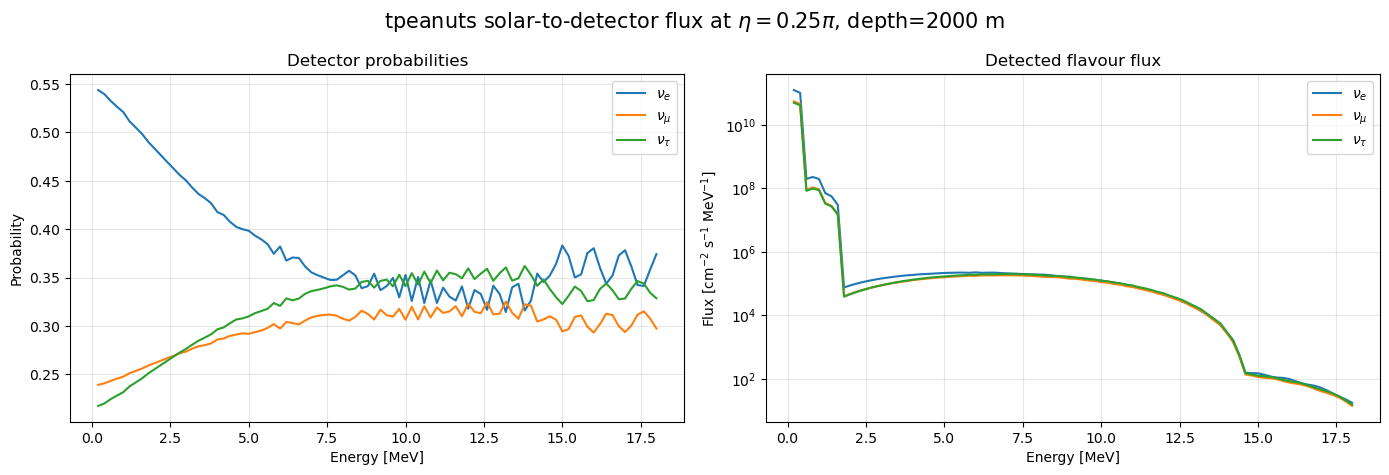

In [11]:
detector_prob_E, detector_flux_E = solar_detector_probability_flux_tpeanuts(ENERGY_MEV, SOLAR_DETECTOR_NADIR)
plot_probability_and_flux(
    ENERGY_MEV,
    detector_prob_E,
    detector_flux_E,
    rf"tpeanuts solar-to-detector flux at $\eta={SOLAR_DETECTOR_NADIR/math.pi:.2f}\pi$, depth={EARTH_DEPTH_M:.0f} m",
)


### 6.2. Nadir-Angle Dependence

This subsection fixes the neutrino energy and shows detector probabilities and detected flavour fluxes as functions of the nadir angle.


Saved figure: V:\output\analysis\solar\analysis_solar2_tpeanuts\figure_007.png


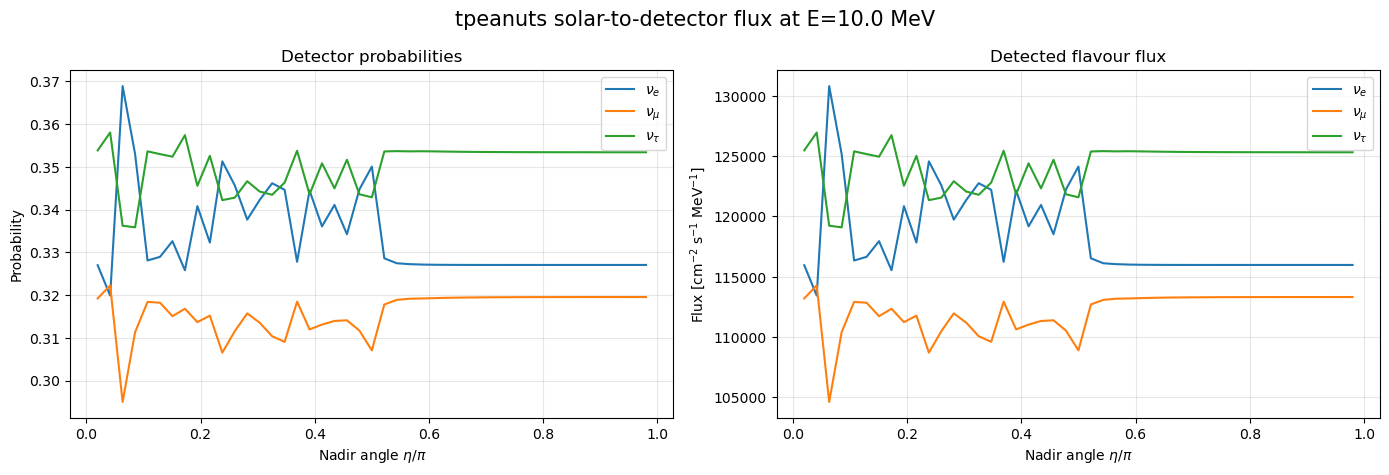

WindowsPath('V:/output/analysis/solar/analysis_solar2_tpeanuts/figure_007.png')

In [12]:
eta_grid = np.linspace(0.02 * math.pi, 0.98 * math.pi, 45)
detector_prob_eta, detector_flux_eta = solar_detector_probability_flux_eta_tpeanuts(eta_grid, SOLAR_DETECTOR_ENERGY_MEV)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharex=True)
for i, label in enumerate(FLAVOUR_LABELS):
    axes[0].plot(eta_grid / math.pi, detector_prob_eta[:, i], label=label)
    axes[1].plot(eta_grid / math.pi, detector_flux_eta[:, i], label=label)
axes[0].set_xlabel(r"Nadir angle $\eta/\pi$")
axes[0].set_ylabel("Probability")
axes[0].set_title("Detector probabilities")
axes[1].set_xlabel(r"Nadir angle $\eta/\pi$")
axes[1].set_ylabel(r"Flux [cm$^{-2}$ s$^{-1}$ MeV$^{-1}$]")
axes[1].set_title("Detected flavour flux")
axes[0].legend()
axes[1].legend()
fig.suptitle(rf"tpeanuts solar-to-detector flux at E={SOLAR_DETECTOR_ENERGY_MEV:.1f} MeV", fontsize=15)
fig.tight_layout()
save_and_show(output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)


## 7. Annual Solar Neutrino Probabilities

This section integrates the solar-to-detector probabilities over the yearly nadir-angle exposure of the configured detector latitude using `tpeanuts.earth.exposure.build_nadir_exposure()`.


In [13]:
def build_configured_nadir_exposure(source: str = NADIR_EXPOSURE_SOURCE):
    return build_nadir_exposure(
        source=source,
        lam_rad=DETECTOR_LATITUDE_RAD,
        d1=0,
        d2=365,
        ns=ANNUAL_NADIR_SAMPLES,
        normalized=True,
        csv_path=str(NADIR_EXPOSURE_CSV),
        angle="Nadir",
        cache_dir=NADIR_EXPOSURE_CACHE_DIR,
        use_cache=(source == "cache"),
        device=DEVICE,
        dtype=DTYPE,
    )


def annual_probability_flux_tpeanuts(energy_mev: np.ndarray) -> tuple[np.ndarray, np.ndarray, object]:
    exposure_table = build_configured_nadir_exposure()
    eta_values = exposure_table.eta.detach().cpu().numpy()
    exposure = exposure_table.exposure.detach().cpu().numpy()
    probability_eta = []
    flux_eta = []
    for eta in eta_values:
        prob, flux = solar_detector_probability_flux_tpeanuts(energy_mev, float(eta))
        probability_eta.append(prob)
        flux_eta.append(flux)
    probability_eta = np.asarray(probability_eta)
    flux_eta = np.asarray(flux_eta)
    annual_prob = np.trapz(probability_eta * exposure[:, None, None], x=eta_values, axis=0)
    annual_flux = np.trapz(flux_eta * exposure[:, None, None], x=eta_values, axis=0)
    return annual_prob, annual_flux, exposure_table


### 7.1. NadirExposure Method Comparison

This subsection compares the four `build_nadir_exposure()` source options on the same normalized yearly exposure grid.


Warning!: Python module pyslha not found, disabling slha reading routines
Saved figure: V:\output\analysis\solar\analysis_solar2_tpeanuts\figure_008.png


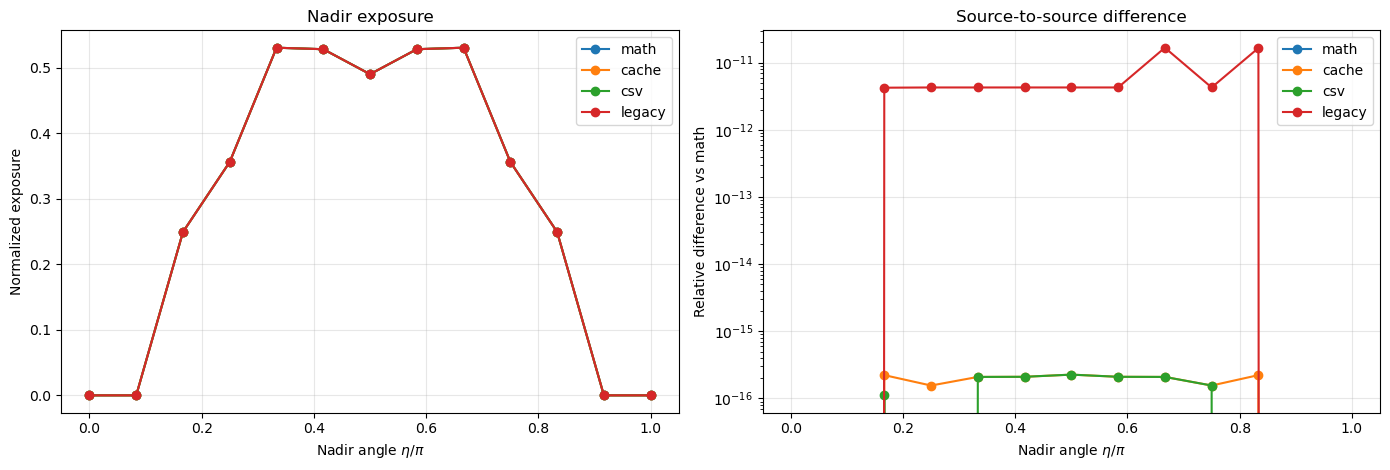

WindowsPath('V:/output/analysis/solar/analysis_solar2_tpeanuts/figure_008.png')

In [14]:

reference_table = build_nadir_exposure(
    source="math",
    lam_rad=DETECTOR_LATITUDE_RAD,
    d1=0,
    d2=365,
    ns=ANNUAL_NADIR_SAMPLES,
    normalized=True,
    cache_dir=NADIR_EXPOSURE_CACHE_DIR,
    use_cache=True,
    device=DEVICE,
    dtype=DTYPE,
)

pd.DataFrame(
    {"Exposure": reference_table.exposure.detach().cpu().numpy()}
).to_csv(NADIR_EXPOSURE_CSV, index=False)

exposure_sources = ["math", "cache", "csv", "legacy"]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharex=True)
reference_eta = reference_table.eta.detach().cpu().numpy()
reference_exposure = reference_table.exposure.detach().cpu().numpy()

for source in exposure_sources:
    table = build_configured_nadir_exposure(source)
    eta = table.eta.detach().cpu().numpy()
    exposure = table.exposure.detach().cpu().numpy()
    exposure_on_reference = np.interp(reference_eta, eta, exposure)
    rel = np.abs(exposure_on_reference - reference_exposure) / np.maximum(np.abs(reference_exposure), 1.0e-30)
    axes[0].plot(eta / math.pi, exposure, marker="o", label=source)
    axes[1].plot(reference_eta / math.pi, rel, marker="o", label=source)

axes[0].set_xlabel(r"Nadir angle $\eta/\pi$")
axes[0].set_ylabel("Normalized exposure")
axes[0].set_title("Nadir exposure")
axes[1].set_xlabel(r"Nadir angle $\eta/\pi$")
axes[1].set_ylabel("Relative difference vs math")
axes[1].set_yscale("log")
axes[1].set_title("Source-to-source difference")
axes[0].legend()
axes[1].legend()
fig.tight_layout()
save_and_show(output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)


### 7.2. Probabilities vs Energy

This subsection plots the annual-exposure-averaged detector probabilities as functions of energy.


Saved figure: V:\output\analysis\solar\analysis_solar2_tpeanuts\figure_009.png


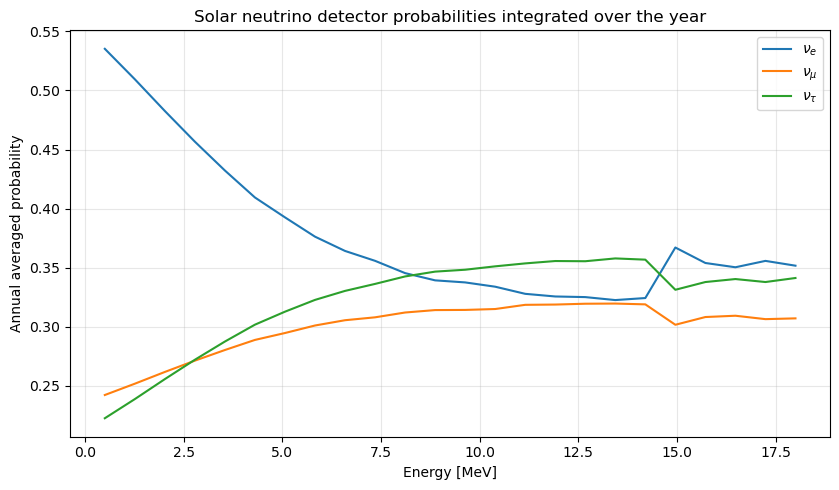

WindowsPath('V:/output/analysis/solar/analysis_solar2_tpeanuts/figure_009.png')

In [15]:
annual_prob_E, annual_flux_E, annual_exposure = annual_probability_flux_tpeanuts(ANNUAL_ENERGY_MEV)

fig, ax = plt.subplots(figsize=(8.5, 5.0))
for i, label in enumerate(FLAVOUR_LABELS):
    ax.plot(ANNUAL_ENERGY_MEV, annual_prob_E[:, i], label=label)
ax.set_xlabel("Energy [MeV]")
ax.set_ylabel("Annual averaged probability")
ax.set_title("Solar neutrino detector probabilities integrated over the year")
ax.legend()
fig.tight_layout()
save_and_show(output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)


### 7.3. Fluxes vs Energy

This subsection plots the annual-exposure-averaged detected flavour fluxes as functions of energy.


Saved figure: V:\output\analysis\solar\analysis_solar2_tpeanuts\figure_010.png


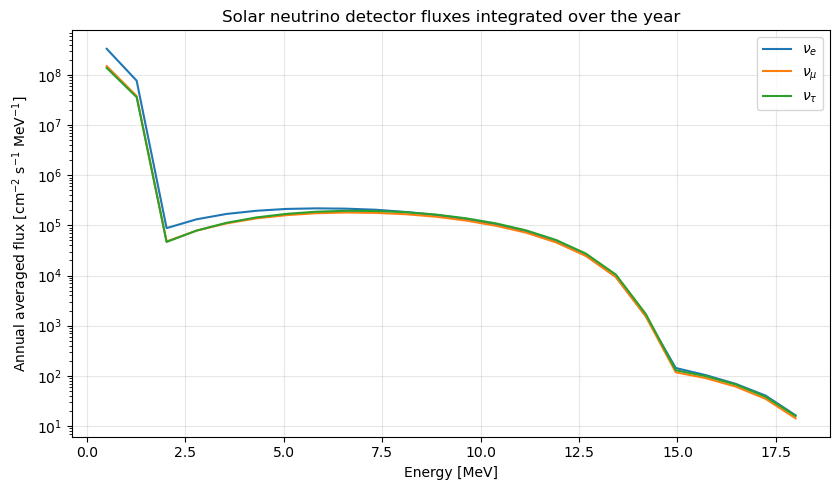

WindowsPath('V:/output/analysis/solar/analysis_solar2_tpeanuts/figure_010.png')

In [16]:
fig, ax = plt.subplots(figsize=(8.5, 5.0))
for i, label in enumerate(FLAVOUR_LABELS):
    ax.plot(ANNUAL_ENERGY_MEV, annual_flux_E[:, i], label=label)
ax.set_xlabel("Energy [MeV]")
ax.set_ylabel(r"Annual averaged flux [cm$^{-2}$ s$^{-1}$ MeV$^{-1}$]")
ax.set_title("Solar neutrino detector fluxes integrated over the year")
ax.set_yscale('log')
ax.legend()
fig.tight_layout()
save_and_show(output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)


## 8. Annual Energy-Integrated Detected Neutrinos

This section integrates the annual flux over energy and builds a bar chart with the total number of neutrinos of each flavour crossing the configured detector area per year.


Saved figure: V:\output\analysis\solar\analysis_solar2_tpeanuts\figure_011.png


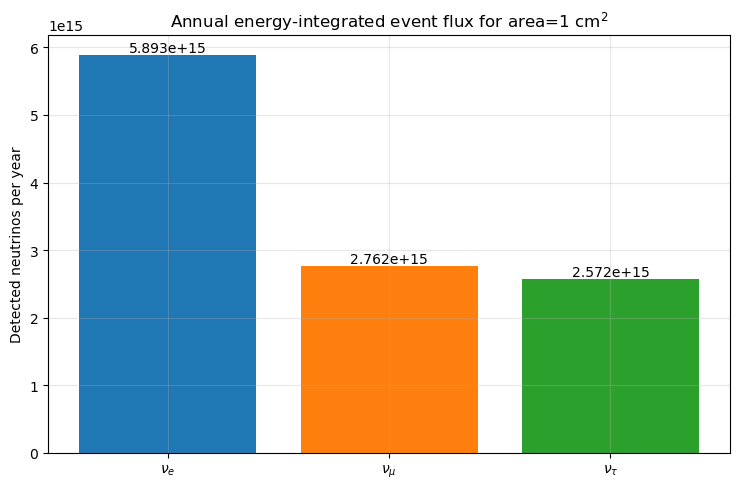

nu_e: 5.892948e+15 neutrinos/year for detector area 1 cm^2
nu_mu: 2.762482e+15 neutrinos/year for detector area 1 cm^2
nu_tau: 2.571763e+15 neutrinos/year for detector area 1 cm^2


In [17]:
detected_per_year = np.trapz(annual_flux_E, x=ANNUAL_ENERGY_MEV, axis=0) * SECONDS_PER_YEAR * DETECTOR_AREA_CM2

fig, ax = plt.subplots(figsize=(7.5, 5.0))
bars = ax.bar([r"$\nu_e$", r"$\nu_\mu$", r"$\nu_\tau$"], detected_per_year, color=["tab:blue", "tab:orange", "tab:green"])
ax.set_ylabel(r"Detected neutrinos per year")
ax.set_title(rf"Annual energy-integrated event flux for area={DETECTOR_AREA_CM2:g} cm$^2$")
ax.bar_label(bars, fmt="%.3e")
fig.tight_layout()
save_and_show(output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

for label, value in zip(["nu_e", "nu_mu", "nu_tau"], detected_per_year):
    print(f"{label}: {value:.6e} neutrinos/year for detector area {DETECTOR_AREA_CM2:g} cm^2")
